# <center>Lab 05 - 112078502 楊婷婷</center>
In this assignment, we would like to predict the success of shots made by basketball players in the NBA.

<img src="fig-nba.png" alt="nba-shot-prediction" width="900"/>

Please download the dataset first. You might need to try with various models to achieve better performance.

## Requirements
- Submit to **eeclass** with your **code file** ```Lab05_{student_id}.ipynb``` (e.g. ```Lab05_114000001.ipynb```) and **prediction file** ```Lab05_{student_id}_y_pred.csv```. The notebook should contain the following parts:
    1. Use all features to train **[any linear model in scikit-learn](https://scikit-learn.org/stable/modules/linear_model.html#linear-models)** and try different hyperparameters (ex. different degree, complexity). Show their performances.
    2. Select 1 setting (model + hyperparameters) and plot the **error curve** to show that the setting you selected **isn't over-fit**.
    3. Use any method to choose the **best 3 features** that can best aid the model's prediction. Explain **how you find it**.
        - Note: the combination of features doesn't count as 1 feature, e.g. $x_1, x_2,$ and $x_1^2+x_2$ count as only two features.
    4. Train the model selected in 2. with the only 3 features selected in 3., and present the training error.
    5. Export the predictions of the model trained in 4. for `X_test` (follow the format of `y_train.csv`).
    6. A **brief report** of what you have done in this assignment.
- Prediction performance will have minimal impact on the assignment grade, so there's no need to be overly concerned about it.
- Deadline: **2025-09-24 (Wed) 23:59**.


## Hints
1. You can **preprocess the data** to help your training.
2. Since you don't have y_test this time, you may need to **split a validation set** for checking your performance.
3. It is possible to use a regression model as a classifier, for example [RidgeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeClassifier.html).

## References
1. [Stanford CS229 Machine Learning](http://cs229.stanford.edu/proj2017/final-reports/5132133.pdf)
2. [NBA shot logs](https://www.kaggle.com/dansbecker/nba-shot-logs)

In [49]:
# inline plotting instead of popping out
%matplotlib inline

import os
from IPython.display import display

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Lasso



import os
if not os.path.exists("output/") : os.mkdir("output/")
if not os.path.exists("data/") : os.mkdir("data/")

import warnings
warnings.filterwarnings("ignore")



In [50]:
# download the dataset
import urllib.request

urllib.request.urlretrieve("https://nthu-datalab.github.io/ml/labs/05_Regularization/data/X_train.csv", "./data/X_train.csv")
urllib.request.urlretrieve("https://nthu-datalab.github.io/ml/labs/05_Regularization/data/y_train.csv", "./data/y_train.csv")
urllib.request.urlretrieve("https://nthu-datalab.github.io/ml/labs/05_Regularization/data/X_test.csv", "./data/X_test.csv")

X_train = pd.read_csv('./data/X_train.csv')
y_train = pd.read_csv('./data/y_train.csv')
X_test = pd.read_csv('./data/X_test.csv')

In [51]:
print(X_train.shape)
print(X_train.columns)
print(y_train.columns)
X_train.head()

(85751, 8)
Index(['PERIOD', 'GAME_CLOCK', 'SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME',
       'SHOT_DIST', 'PTS_TYPE', 'CLOSE_DEF_DIST'],
      dtype='object')
Index(['FGM'], dtype='object')


,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,SHOT_DIST,PTS_TYPE,CLOSE_DEF_DIST
0,1,358,2.4,0,3.2,20.6,2,4.5
1,1,585,8.3,0,1.2,3.0,2,0.5
2,1,540,19.9,0,0.6,3.5,2,3.2
3,1,392,9.0,0,0.9,21.1,2,4.9
4,3,401,22.7,0,0.7,4.1,2,2.9


In [52]:
# split X into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=0)

print('#Training data points: %d' % X_train.shape[0])
print('#Validation data points: %d' % X_val.shape[0])
print('#Testing data points: %d' % X_test.shape[0])
print('Class labels:', np.unique(y_train))

#Training data points: 60025
#Validation data points: 25726
#Testing data points: 36751
Class labels: [0 1]


In [53]:
# --- Standardize ---
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_val_std = scaler.transform(X_val)

## Requirement 1
Use all features to train **[any linear model in scikit-learn](https://scikit-learn.org/stable/modules/linear_model.html#linear-models)**
and try different hyperparameters (ex. different degree, complexity). Show their performances.

### model picked 
### 1-1 : Logistic Regression
the model use full data set for solver, time-consuming

different hyperparameters:
* (1) degree : 1 to 3 
* (2) as from above, the degree 2 is the best fixed with degree = 2, try different C :
the smaller C, the model is simpler


Different parameter (1) degrees: 1 to 3 
[degree=1] training=0.608, validation=0.609
[degree=2] training=0.616, validation=0.614
[degree=3] training=0.619, validation=0.613


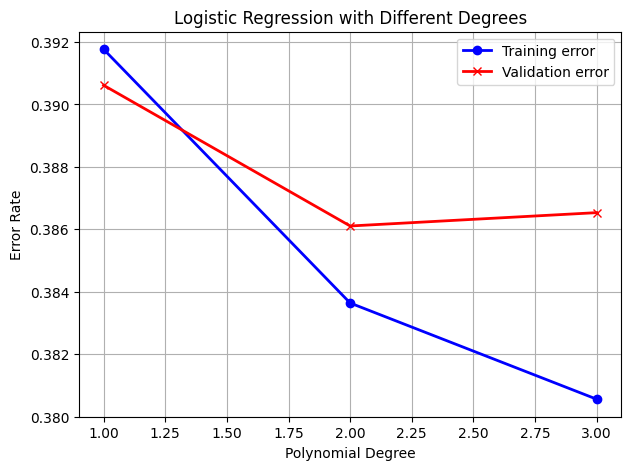


Different parameter (1) C: 10^-6 to 1, degree = 2, alpha 
[C=1.0e-06] training=0.568, validation=0.561
[C=6.0e-06] training=0.595, validation=0.589
[C=3.6e-05] training=0.603, validation=0.603
[C=2.2e-04] training=0.611, validation=0.610
[C=1.3e-03] training=0.616, validation=0.614
[C=7.7e-03] training=0.616, validation=0.614
[C=4.6e-02] training=0.616, validation=0.614
[C=2.8e-01] training=0.616, validation=0.614
[C=1.7e+00] training=0.616, validation=0.614
[C=1.0e+01] training=0.616, validation=0.614


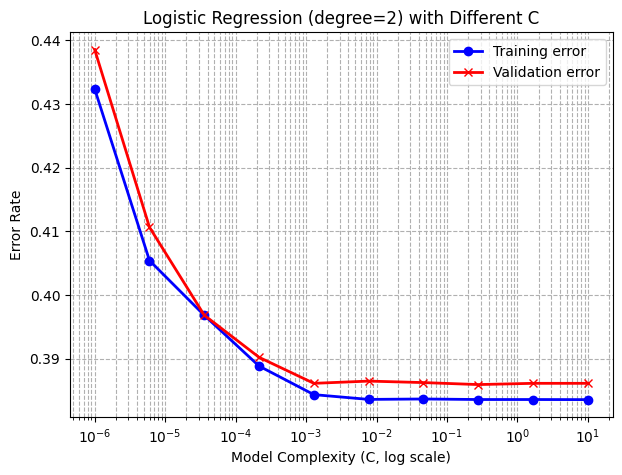

In [54]:
# (1) Polynomial degree 1 to 3 
degree_list = [1, 2, 3]
train_err_list, val_err_list = [], []

print("Different parameter (1) degrees: 1 to 3 ")
for d in degree_list:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_std)
    X_val_poly = poly.transform(X_val_std)

    clf = LogisticRegression(solver="liblinear", C=1.0, max_iter=2000)
    clf.fit(X_train_poly, y_train.values.ravel())

    train_acc = clf.score(X_train_poly, y_train)
    val_acc = clf.score(X_val_poly, y_val)

    train_err_list.append(1 - train_acc)
    val_err_list.append(1 - val_acc)

    print(f"[degree={d}] training={train_acc:.3f}, validation={val_acc:.3f}")

plt.figure(figsize=(7,5))
plt.plot(degree_list, train_err_list, 'bo-', label="Training error", linewidth=2)
plt.plot(degree_list, val_err_list, 'rx-', label="Validation error", linewidth=2)
plt.xlabel("Polynomial Degree")
plt.ylabel("Error Rate")
plt.title("Logistic Regression with Different Degrees")
plt.legend()
plt.grid(True)
plt.show()


# (2) regulization factor C : 10^-6 to 10^1

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_std)
X_val_poly = poly.transform(X_val_std)

C_list = np.logspace(-6, 1, 10)   
train_err_list, val_err_list = [], []

print("\nDifferent parameter (1) C: 10^-6 to 1, degree = 2, alpha ")
for c in C_list:
    clf = LogisticRegression(solver="liblinear", C=c, max_iter=2000)
    clf.fit(X_train_poly, y_train.values.ravel())

    train_acc = clf.score(X_train_poly, y_train)
    val_acc = clf.score(X_val_poly, y_val)

    train_err_list.append(1 - train_acc)
    val_err_list.append(1 - val_acc)

    print(f"[C={c:.1e}] training={train_acc:.3f}, validation={val_acc:.3f}")

plt.figure(figsize=(7,5))
plt.semilogx(C_list, train_err_list, 'bo-', label="Training error", linewidth=2)
plt.semilogx(C_list, val_err_list, 'rx-', label="Validation error", linewidth=2)
plt.xlabel("Model Complexity (C, log scale)")
plt.ylabel("Error Rate")
plt.title("Logistic Regression (degree=2) with Different C")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()





### model picked 
### 1-2 : SGD classifier
update weights on one mini-bastch -> quicker 

different hyperparameters: 
* (1) degree 1 to 3 
* (2) alpha : regulization strenth  the Smaller alpha, the weaker penalty -> model are more complex
* (3) differnt loss (what kind of linaer classifier it is) : four try hinge, log_loss, perception, modified _huber,squaere_hinge 
* (4) regularization type : l1 and l2 , elasticnet with set 0.5 0.5


SGDClassifier: Degree sweep (loss='log_loss', penalty='l2')
[degree=1] train=0.607, val=0.606
[degree=2] train=0.615, val=0.612
[degree=3] train=0.594, val=0.592


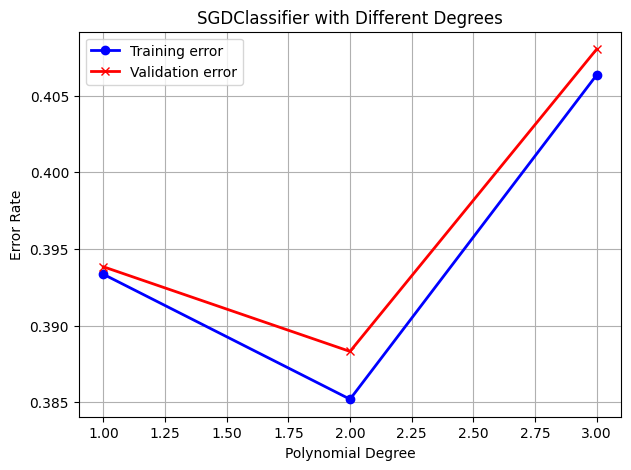


SGDClassifier: Alpha sweep (loss='log_loss', penalty='elasticnet')
[alpha=1.0e-06] train=0.542, val=0.537
[alpha=6.0e-06] train=0.541, val=0.540
[alpha=3.6e-05] train=0.591, val=0.589
[alpha=2.2e-04] train=0.606, val=0.600
[alpha=1.3e-03] train=0.610, val=0.608
[alpha=7.7e-03] train=0.616, val=0.612
[alpha=4.6e-02] train=0.615, val=0.612
[alpha=2.8e-01] train=0.609, val=0.609
[alpha=1.7e+00] train=0.598, val=0.596
[alpha=1.0e+01] train=0.467, val=0.471


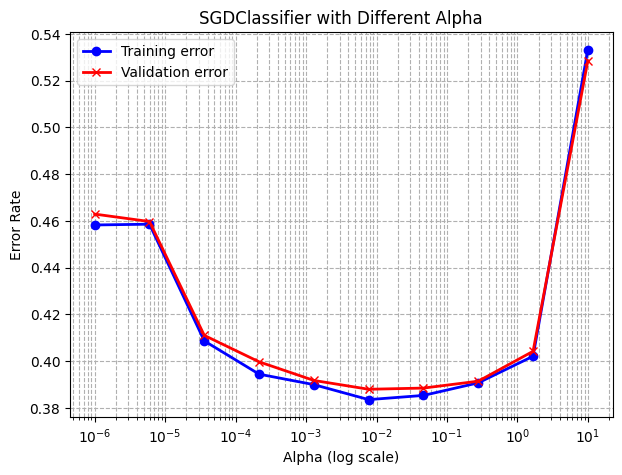


SGDClassifier: Loss function comparison (degree=2, L2)
[loss=hinge] train=0.617, val=0.612
[loss=log_loss] train=0.615, val=0.612
[loss=perceptron] train=0.540, val=0.539
[loss=modified_huber] train=0.611, val=0.609
[loss=squared_hinge] train=0.487, val=0.495

SGDClassifier: Penalty comparison (degree=2, loss='log_loss')
[penalty=l1] train=0.616, val=0.612
[penalty=l2] train=0.615, val=0.612
[penalty=elasticnet] train=0.615, val=0.613

Grouped Results (Loss Functions vs Penalties):
         Type        Setting  Train Error  Validation Error
Loss Function          hinge     0.383324          0.388051
Loss Function       log_loss     0.385206          0.388323
Loss Function     perceptron     0.460491          0.460546
Loss Function modified_huber     0.389421          0.390694
Loss Function  squared_hinge     0.513269          0.504548
      Penalty             l1     0.383940          0.387585
      Penalty             l2     0.385206          0.388323
      Penalty     elasticnet    

In [55]:

# (1) Polynomial degree sweep (fixed loss/log_loss, L2)
degrees = [1, 2, 3]
train_err, val_err = [], []

print("SGDClassifier: Degree sweep (loss='log_loss', penalty='l2')")
for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_std)
    X_val_poly = poly.transform(X_val_std)

    clf = SGDClassifier(loss="log_loss", penalty="l2", alpha=0.001,
                        max_iter=1000, random_state=0)
    clf.fit(X_train_poly, y_train.values.ravel())

    train_acc = clf.score(X_train_poly, y_train)
    val_acc = clf.score(X_val_poly, y_val)

    train_err.append(1 - train_acc)
    val_err.append(1 - val_acc)

    print(f"[degree={d}] train={train_acc:.3f}, val={val_acc:.3f}")

plt.figure(figsize=(7,5))
plt.plot(degrees, train_err, "bo-", label="Training error", linewidth=2)
plt.plot(degrees, val_err, "rx-", label="Validation error", linewidth=2)
plt.xlabel("Polynomial Degree")
plt.ylabel("Error Rate")
plt.title("SGDClassifier with Different Degrees")
plt.legend()
plt.grid(True)
plt.show()


# (2) Alpha regulization strength 

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_std)
X_val_poly = poly.transform(X_val_std)

alpha_list = np.logspace(-6, 1, 10)
train_err, val_err = [], []

print("\nSGDClassifier: Alpha sweep (loss='log_loss', penalty='elasticnet')")
for a in alpha_list:
    clf = SGDClassifier(loss="log_loss", penalty="l2", alpha=a,
                        max_iter=1000, random_state=0)
    clf.fit(X_train_poly, y_train.values.ravel())

    train_acc = clf.score(X_train_poly, y_train)
    val_acc = clf.score(X_val_poly, y_val)

    train_err.append(1 - train_acc)
    val_err.append(1 - val_acc)

    print(f"[alpha={a:.1e}] train={train_acc:.3f}, val={val_acc:.3f}")

plt.figure(figsize=(7,5))
plt.semilogx(alpha_list, train_err, "bo-", label="Training error", linewidth=2)
plt.semilogx(alpha_list, val_err, "rx-", label="Validation error", linewidth=2)
plt.xlabel("Alpha (log scale)")
plt.ylabel("Error Rate")
plt.title("SGDClassifier with Different Alpha")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


# (3) Different loss functions

losses = ["hinge", "log_loss", "perceptron", "modified_huber", "squared_hinge"]
train_err, val_err = [], []
loss_results = []

print("\nSGDClassifier: Loss function comparison (degree=2, L2)")
for loss in losses:
    clf = SGDClassifier(loss=loss, penalty="l2", alpha=0.001,
                        max_iter=1000, random_state=0)
    clf.fit(X_train_poly, y_train.values.ravel())

    train_acc = clf.score(X_train_poly, y_train)
    val_acc = clf.score(X_val_poly, y_val)

    train_err.append(1 - train_acc)
    val_err.append(1 - val_acc)
    loss_results.append(["Loss Function", loss, 1-train_acc, 1-val_acc])

    print(f"[loss={loss}] train={train_acc:.3f}, val={val_acc:.3f}")


# (4) Different penalties (L1, L2, ElasticNet)
penalties = ["l1", "l2", "elasticnet"]
train_err, val_err = [], []
penalty_results = []

print("\nSGDClassifier: Penalty comparison (degree=2, loss='log_loss')")
for pen in penalties:
    clf = SGDClassifier(loss="log_loss", penalty=pen, alpha=0.001,
                        l1_ratio=0.5 if pen=="elasticnet" else 0.0,
                        max_iter=1000, random_state=0)
    clf.fit(X_train_poly, y_train.values.ravel())

    train_acc = clf.score(X_train_poly, y_train)
    val_acc = clf.score(X_val_poly, y_val)

    train_err.append(1 - train_acc)
    val_err.append(1 - val_acc)
    penalty_results.append(["Penalty", pen, 1-train_acc, 1-val_acc])

    print(f"[penalty={pen}] train={train_acc:.3f}, val={val_acc:.3f}")



# Combine with a "Type" column
results_df = pd.DataFrame(
    loss_results + penalty_results,
    columns=["Type", "Setting", "Train Error", "Validation Error"]
)

print("\nGrouped Results (Loss Functions vs Penalties):")
print(results_df.to_string(index=False))


## Requirement 2
2. Select 1 setting (model + hyperparameters) and plot the **error curve** to show that the setting you selected **isn't over-fit**.

I will choose the second model (SGDClassifier), as the runtime is much faster. 
From above , the final the hyperparameter will be 
* (1) degree = 2
* (2) Alpha $\alpha$= $10^{-2}$
* (3) Loss Function : log_loss
* (4) Penalty: elasticnet l2

At $\alpha = 10^{-2}$ observe the error curve above, it is not overfitting. Good fit : Training error is low and validation error is close to it.

### model picked 
### 1-3 :Ridge Classifier


different hyperparameters:  alpha


Ridge Classifier (degree=2) Results :
[alpha=1.0e-03] training=0.618, validation=0.615
[alpha=3.7e-03] training=0.618, validation=0.615
[alpha=1.4e-02] training=0.618, validation=0.615
[alpha=5.2e-02] training=0.618, validation=0.615
[alpha=1.9e-01] training=0.618, validation=0.615
[alpha=7.2e-01] training=0.618, validation=0.615
[alpha=2.7e+00] training=0.618, validation=0.615
[alpha=1.0e+01] training=0.618, validation=0.615
[alpha=3.7e+01] training=0.618, validation=0.615
[alpha=1.4e+02] training=0.618, validation=0.614
[alpha=5.2e+02] training=0.617, validation=0.614
[alpha=1.9e+03] training=0.618, validation=0.613
[alpha=7.2e+03] training=0.616, validation=0.612
[alpha=2.7e+04] training=0.613, validation=0.611
[alpha=1.0e+05] training=0.606, validation=0.603


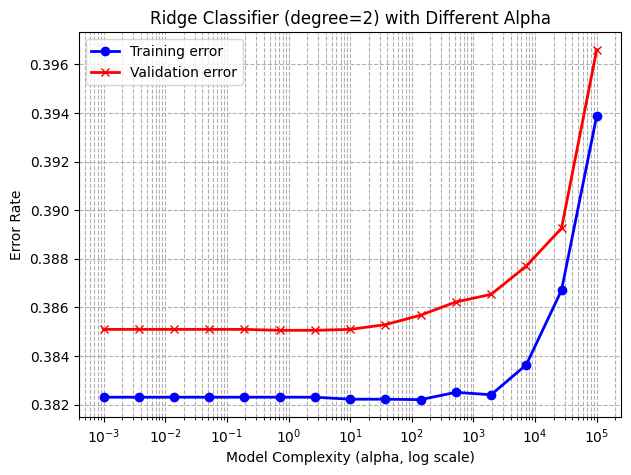

In [56]:

alpha_list = np.logspace(-3, 5, 15)   # from 1e-3 to 1e+3
train_err_list, val_err_list = [], []

print("\nRidge Classifier (degree=2) Results :")
for a in alpha_list:
    clf = RidgeClassifier(alpha=a, max_iter=2000)
    clf.fit(X_train_poly, y_train.values.ravel())

    train_acc = clf.score(X_train_poly, y_train)
    val_acc = clf.score(X_val_poly, y_val)

    train_err_list.append(1 - train_acc)
    val_err_list.append(1 - val_acc)

    print(f"[alpha={a:.1e}] training={train_acc:.3f}, validation={val_acc:.3f}")

plt.figure(figsize=(7,5))
plt.semilogx(alpha_list, train_err_list, 'bo-', label="Training error", linewidth=2)
plt.semilogx(alpha_list, val_err_list, 'rx-', label="Validation error", linewidth=2)
plt.xlabel("Model Complexity (alpha, log scale)")
plt.ylabel("Error Rate")
plt.title("Ridge Classifier (degree=2) with Different Alpha")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


## Requirement 3
3. Use any method to choose the **best 3 features** that can best aid the model's prediction. Explain **how you find it**.
- Note: the combination of features doesn't count as 1 feature, e.g. $x_1, x_2,$ and $x_1^2+x_2$ count as only two features.

In [57]:
# run LASSO for feature selection
lasso = Lasso(alpha=0.02, random_state=0)  # alpha: sparsity
lasso.fit(X_train_std, y_train)

# get top 3 features
coef_abs = np.abs(lasso.coef_)
top3_idx = np.argsort(coef_abs)[-3:][::-1] # sort by coefficient size, get the last 3
top3_features = X_train.columns[top3_idx]
print("Top 3 features from LASSO:", top3_features.tolist())

Top 3 features from LASSO: ['SHOT_DIST', 'CLOSE_DEF_DIST', 'SHOT_CLOCK']


## Requirement 4
4. Train the model selected in 2. with the only 3 features selected in 3., and present the training error.

In [60]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDClassifier

# keep only top3 features
X_train_sel = X_train_std[:, top3_idx]
X_val_sel = X_val_std[:, top3_idx]

# polynomial expansion (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_sel)
X_val_poly = poly.transform(X_val_sel)

# final model with chosen hyperparams
clf = SGDClassifier(
    loss="log_loss", 
    penalty="elasticnet", 
    alpha=1e-2,       
    l1_ratio=0.5,     # elasticnet mixing
    max_iter=2000,
    random_state=0
)
clf.fit(X_train_poly, y_train.values.ravel())

train_acc = clf.score(X_train_poly, y_train)
val_acc = clf.score(X_val_poly, y_val)
train_err = 1 - train_acc
val_err = 1 - val_acc

print(f"Final Model -> Train Acc={train_acc:.3f}, Error={train_err:.3f} | "
      f"Val Acc={val_acc:.3f}, Error={val_err:.3f}")


Final Model -> Train Acc=0.614, Error=0.386 | Val Acc=0.613, Error=0.387


## Requirement 5   
5. Export the predictions of the model trained in 4. for `X_test` (follow the format of `y_train.csv`).

In [59]:

X_test_std = scaler.transform(X_test)


X_test_sel = X_test_std[:, top3_idx]

X_test_poly = poly.transform(X_test_sel)

# Predict with final model
y_test_pred = clf.predict(X_test_poly)

# Save to CSV (follow y_train.csv format)
y_pred_df = pd.DataFrame(y_test_pred, columns=["FGM"])
y_pred_df.to_csv("Lab05_112078502_y_pred.csv", index=False)

print("Prediction file saved: Lab05_112078502_y_pred.csv")


Prediction file saved: Lab05_112078502_y_pred.csv


## Requirement 6
A **brief report** of what you have done in this assignment.


### Ans:

I first experimented with Logistic Regression and SGDClassifier, testing different polynomial degrees, regularization strengths (C / alpha), loss functions, and penalties to study their effect on training and validation performance. 
  
To reduce dimensionality, I used LASSO regression to identify the top three most important features. Finally, I trained an SGDClassifier with degree = 2, alpha = 10⁻², log_loss, and elasticnet penalty on the selected features, and exported predictions for the test set in the required format.

